# CineMetrix

# Phase 3: Exploratory Data Analysis

## Objective

This notebook answers business questions using the cleaned Netflix dataset.

Instead of describing the data, the goal is to discover insights that can be transformed into dashboard visuals and business recommendations.

## Saved Visualizations

Final dashboard-quality charts are exported automatically to the `images/` directory for documentation and reporting purposes.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../images", exist_ok=True)

NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#141414"
NETFLIX_WHITE = "#FFFFFF"
NETFLIX_GRAY = "#B3B3B3"

plt.style.use("dark_background")

In [98]:
def save_chart(filename):
    plt.savefig(
        f"../images/{filename}",
        dpi=300,
        facecolor="#141414",
        bbox_inches="tight"
    )

In [99]:
df = pd.read_csv("../data/processed/netflix_clean.csv")
country_df = pd.read_csv("../data/processed/netflix_country_exploded.csv")
genre_df = pd.read_csv("../data/processed/netflix_genre_exploded.csv")

In [100]:
df.shape

(7787, 14)

In [101]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,movie_minutes,seasons
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,NaN,4.0
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,143.0,NaN
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,124.0,NaN
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,90.0,NaN
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,NaN,1.0


# Business Question 1

## How has Netflix's content library evolved over time?

We investigate whether Netflix's catalog expanded gradually or experienced periods of rapid growth.

## Hypothesis

Netflix's catalog is expected to expand rapidly after the growth of global streaming platforms.

In [102]:
yearly = (
    df.groupby("release_year")
      .size()
      .reset_index(name="Titles")
)

yearly.tail(20)

,release_year,Titles
53,2002,45
54,2003,49
55,2004,59
56,2005,73
57,2006,85
58,2007,85
59,2008,125
60,2009,137
61,2010,173
62,2011,166


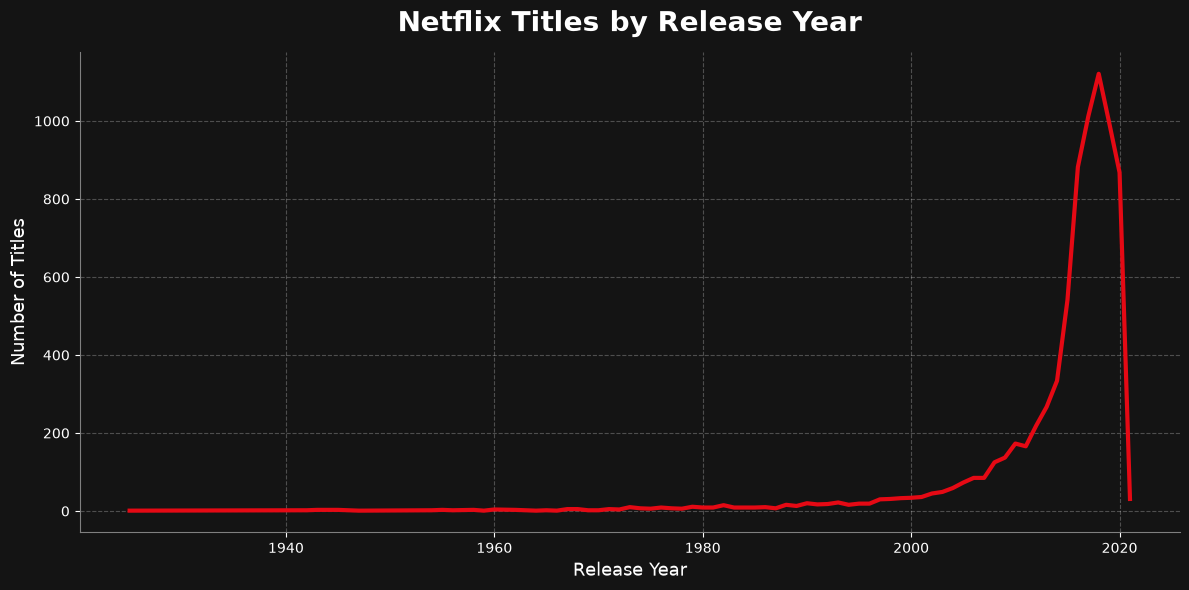

In [103]:
plt.figure(figsize=(12,6), facecolor=NETFLIX_BLACK)
ax = plt.gca()
ax.set_facecolor(NETFLIX_BLACK)

plt.plot(
    yearly["release_year"],
    yearly["Titles"],
    color=NETFLIX_RED,
    linewidth=3
)

plt.title(
    "Netflix Titles by Release Year",
    fontsize=20,
    fontweight="bold",
    color="white",
    pad=15
)

plt.xlabel(
    "Release Year",
    fontsize=13,
    color="white"
)

plt.ylabel(
    "Number of Titles",
    fontsize=13,
    color="white"
)

plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.xticks(color="white")
plt.yticks(color="white")

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("gray")
ax.spines["bottom"].set_color("gray")

plt.tight_layout()
save_chart("titles_by_year.png")
plt.show()

In [104]:
df['date_added'].max()

'2021-01-16'

## Observation

The number of Netflix titles remained relatively low until around 2014–2015. 
After 2015, the catalog expanded rapidly, reaching its peak around 2018–2019. 
A sharp decline is observed after 2020, the dataset's collection ends in 16 January 2021, which explains the decline , its data boundary not a real drop content 

## Business Insight

The rapid growth after 2015 suggests that Netflix aggressively expanded its content library to attract and retain subscribers in the increasingly competitive streaming market. 

This indicates that content volume became a key strategic driver of platform growth, making investment in original and diverse content an important business strategy.

## Dashboard Candidate

✅ Yes

Reason:
A trend comparison between Movies and TV Shows can effectively communicate Netflix's content strategy over time.

# Business Question 2

## Has Netflix shifted its strategy from Movies to TV Shows over time?

This analysis investigates whether Netflix's content strategy has evolved from primarily producing movies to increasing investment in TV shows.

## Hypothesis

With the rise of binge-watching culture and streaming platforms, Netflix may have increasingly invested in TV shows alongside movies.

In [105]:
movie_tv = pd.crosstab(
    df['release_year'],
    df['type']
)

movie_tv.tail(15)

type,Movie,TV Show
release_year,,
2007,72,13
2008,102,23
2009,103,34
2010,136,37
2011,127,39
2012,158,61
2013,202,65
2014,244,90
2015,382,159


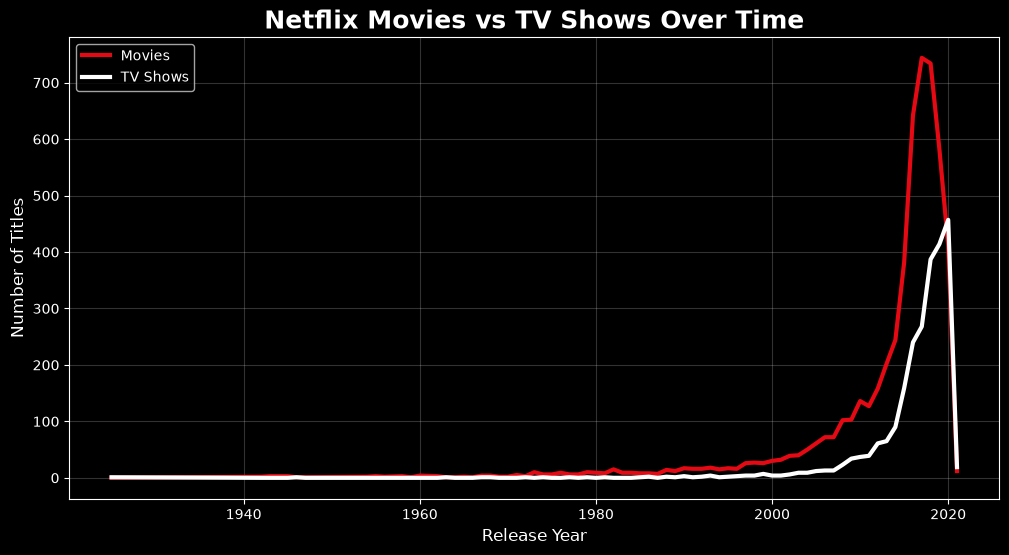

In [106]:
plt.figure(figsize=(12,6))

plt.plot(
    movie_tv.index,
    movie_tv["Movie"],
    color=NETFLIX_RED,
    linewidth=3,
    label="Movies"
)

plt.plot(
    movie_tv.index,
    movie_tv["TV Show"],
    color=NETFLIX_WHITE,
    linewidth=3,
    label="TV Shows"
)

plt.title(
    "Netflix Movies vs TV Shows Over Time",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

plt.legend()

plt.grid(alpha=0.2)
save_chart("movies_vs_tvshows.png")
plt.show()

## Observation

Movies consistently outnumber TV Shows across all release years.

Both content types experienced strong growth after 2015, but TV Shows expanded at a faster rate during the late 2010s.

The decline after 2020 is likely caused by dataset collection timing rather than an actual collapse in content production.

## Business Insight

Netflix appears to maintain Movies as the foundation of its catalog while increasingly investing in TV Shows.

The rapid growth in TV Shows suggests a strategic focus on subscriber retention, as episodic content encourages longer viewing sessions and repeat platform engagement.

## Dashboard Candidate

✅ Yes

Reason:

This comparison clearly communicates Netflix's content strategy and helps stakeholders understand how the platform balanced Movies and TV Shows over time.

# Business Question 3

Which countries contribute the most content to Netflix?

## Hypothesis

The United States is expected to contribute the highest number of titles, followed by large entertainment-producing countries such as India and the United Kingdom.

In [107]:
top_countries = country_df["country"].value_counts().head(10)
top_countries

country
United States     3296
India              990
United Kingdom     722
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

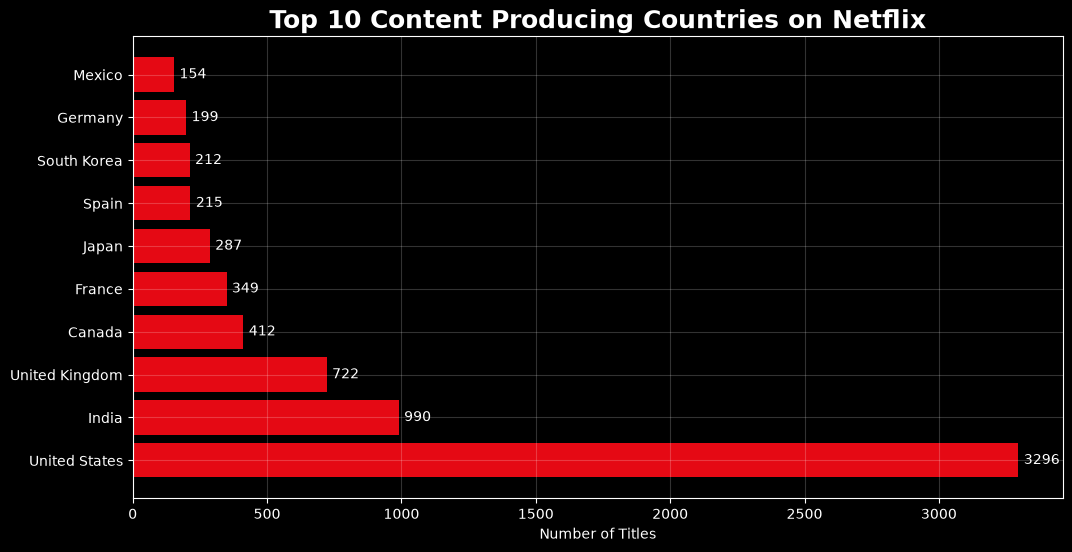

In [108]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    top_countries.index,
    top_countries.values,
    color=NETFLIX_RED
)

for bar in bars:
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.title(
    "Top 10 Content Producing Countries on Netflix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.grid(alpha=0.2)
save_chart("top_countries.png")
plt.show()


## Observation

The United States contributes the highest number of titles on Netflix, accounting for a substantially larger catalog than any other country.

India ranks second, followed by the United Kingdom, Canada, and France.

The distribution is highly concentrated, with a few countries contributing the majority of available content.

## Dashboard Candidate

✅ Yes

Reason:

Geographic content distribution is a key business metric and helps stakeholders understand where Netflix sources most of its content.

In [109]:
top_countries.sum()

np.int64(6836)

In [110]:
top10_list = top_countries.index.tolist()
has_top10 = df['country'].fillna('').apply(lambda x: any(c in top10_list for c in x.split(', ')))
correct_pct = has_top10.mean() * 100

In [111]:
correct_pct

np.float64(76.12687813021702)

## Business Insight

Netflix's content library relies heavily on major entertainment-producing markets, particularly the United States and India.Top 10 contribute about 76.1 percent of the total content.

Netflix'Content Sourcing leans more on Western co-production partnerships (Canada,France) than the original notebook suggested , and the presence of genuinely Asian markets luke Japan and South Korea , still meaningful, ranks below those Western partners one countries are correctly counted

# Business Question 4

What are the most popular content ratings on Netflix?

## Hypothesis

Netflix is expected to focus primarily on mature audiences, with TV-MA and TV-14 being the most common content ratings.

In [112]:
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

## Observation

TV-MA is the most common content rating on Netflix, followed by TV-14.

Together, these two ratings account for the majority of titles in the catalog, while children's ratings such as TV-Y and TV-Y7 represent a much smaller share.

## Business Insight

Netflix primarily targets mature and young-adult audiences rather than children.

More than 60% of titles fall under TV-MA and TV-14, indicating a strong focus on content designed for teenagers and adults.

This strategy allows Netflix to compete through a broad library of dramas, thrillers, crime series, documentaries, and other high-engagement content categories.

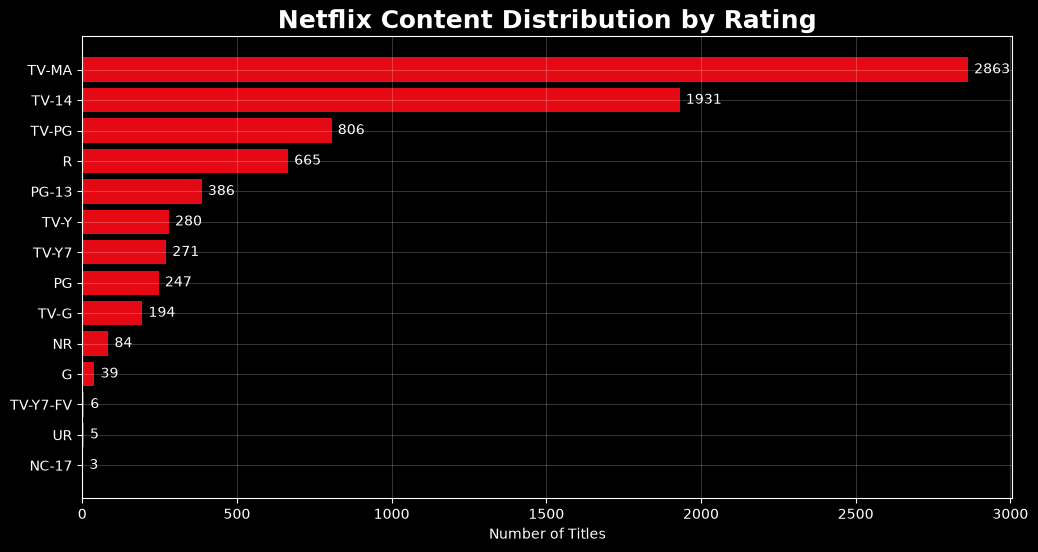

In [113]:
plt.style.use("dark_background")

rating_counts = df["rating"].value_counts()

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    rating_counts.index[::-1],
    rating_counts.values[::-1],
    color=NETFLIX_RED
)

for bar in bars:
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center"
    )

plt.title(
    "Netflix Content Distribution by Rating",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Titles")

plt.grid(alpha=0.2)
save_chart("ratings_distribution.png")
plt.show()

## Dashboard Candidate

✅ Yes

Reason:

Content ratings are an important segmentation metric and help stakeholders understand audience targeting strategies across the Netflix catalog.

# Business Question 5

## Which genres dominate Netflix's catalog?

## Hypothesis

Drama, Comedy, and International content are expected to dominate Netflix's catalog due to their broad audience appeal and global reach.

In [114]:
genre_df["genres"].head()

0    International TV Shows
1                 TV Dramas
2       TV Sci-Fi & Fantasy
3             Horror Movies
4      International Movies
Name: genres, dtype: str

In [115]:
genre_counts = (
    genre_df["genres"]
    .value_counts()
    .head(15)
)

genre_counts

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  525
Thrillers                    491
Crime TV Shows               427
Kids' TV                     414
Docuseries                   353
Name: count, dtype: int64

## Observation

International Movies is the most common genre category on Netflix, followed by Dramas and Comedies.

Both International Movies and International TV Shows rank among the top content categories, indicating a strong presence of globally produced content in the catalog.

## Business Insight

Netflix's catalog strategy is heavily focused on international content rather than relying solely on Hollywood productions.

The strong representation of International Movies and International TV Shows suggests that Netflix invests significantly in localized content to attract and retain subscribers across different regions.

This diversified content strategy helps Netflix scale globally while reducing dependence on a single market.

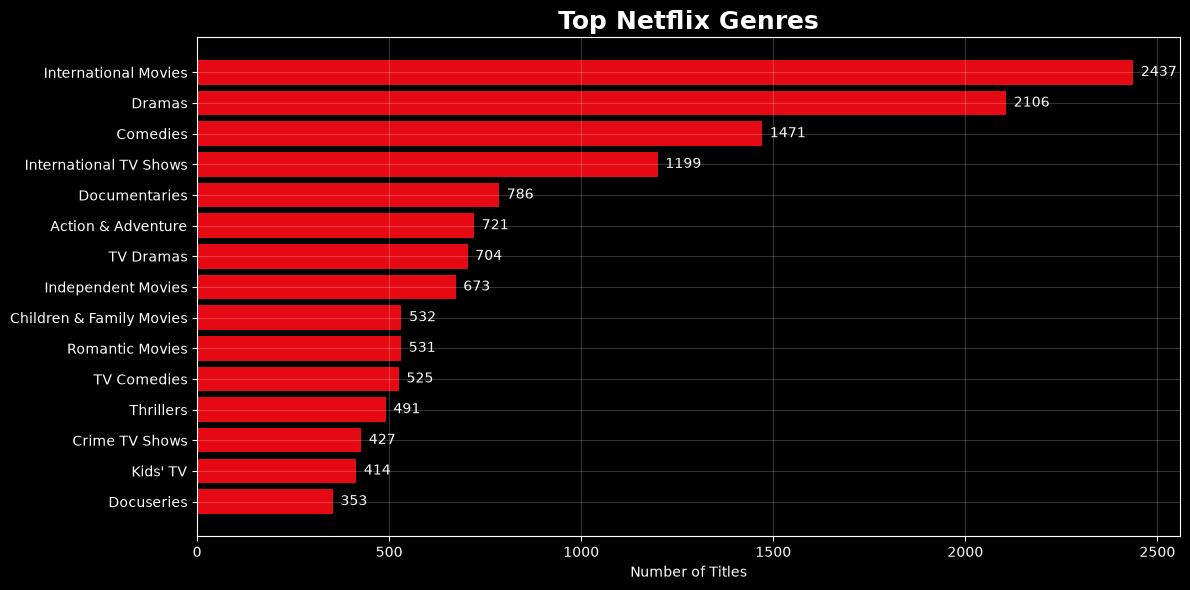

In [116]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    genre_counts.index[::-1],
    genre_counts.values[::-1],
    color=NETFLIX_RED
)

for bar in bars:
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center",
        color="white"
    )

plt.title(
    "Top Netflix Genres",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Titles")

plt.grid(alpha=0.2)

plt.tight_layout()
save_chart("genres_distribution.png")
plt.show()

## Dashboard Candidate

✅ Yes

Reason:

Genre distribution is one of the most important content portfolio metrics and helps stakeholders understand content investment priorities.

# Business Question 6

## Which countries produce the highest number of Movies vs TV Shows?

## Hypothesis

Different countries are expected to specialize in different content types.

The United States and India are expected to contribute primarily Movies, while countries such as South Korea and the United Kingdom may have a stronger representation of TV Shows.

In [117]:
from scipy import stats

top5 = country_df['country'].value_counts().head(5).index
sub = country_df[country_df['country'].isin(top5)]
ct = pd.crosstab(sub['country'], sub['type'])

chi2, p, dof, exp = stats.chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}, p-value: {p:.5f}, Cramér's V: {cramers_v:.3f}")

Chi-square: 214.67, p-value: 0.00000, Cramér's V: 0.193


### Chi-Square Test: Country vs Content Type

- χ² = 214.67
- p < 0.001
- Cramér's V = 0.193

The chi-square test indicates a statistically significant association between country and content type (Movie vs TV Show). However, Cramér's V suggests that this association is weak. This implies that while content composition differs across countries, country is not a strong predictor of whether a title is a movie or a TV show.

Since the p-value is extremely small (p < 0.001), we reject the null hypothesis. This indicates that the distribution of Movies and TV Shows differs significantly across countries.
However, Cramér's V = 0.193 indicates that the strength of this association is weak. In other words, while country and content type are statistically related, the relationship is not very strong.

## Business Insight

The proportion of Movies and TV Shows varies by country. For example, countries such as the United States and India are more movie-dominated, whereas countries like South Korea and the United Kingdom have a relatively higher share of TV Shows. Although these differences are statistically significant, country alone does not strongly determine the type of content available.

In [118]:
country_type = pd.crosstab(
    country_df["country"], 
    country_df["type"])

country_type.sort_values(
    by="Movie",
    ascending=False
).head(10)

type,Movie,TV Show
country,,
United States,2430,866
India,915,75
United Kingdom,466,256
Canada,286,126
France,265,84
Spain,158,57
Germany,157,42
Japan,103,184
China,102,45


## Observation

The United States contributes the highest number of both Movies and TV Shows.

India's contribution is heavily concentrated in Movies, while countries such as Japan and the United Kingdom show a stronger balance between Movies and TV Shows.

Content production patterns vary significantly across countries.

## Business Insight

Netflix relies on different regions for different content formats.

India serves primarily as a source of movie content, whereas countries such as Japan and the United Kingdom contribute a larger proportion of serialized television content.

This diversification enables Netflix to build a balanced global catalog that caters to varying audience preferences.

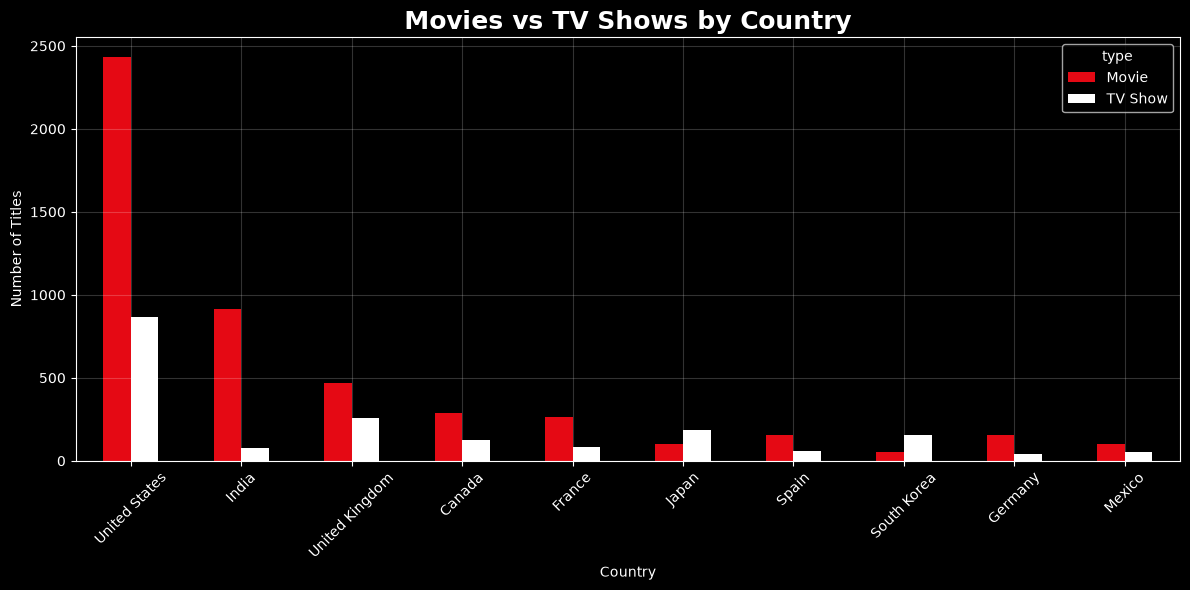

In [119]:
top_countries = country_type.sum(axis=1).nlargest(10).index

country_chart = country_type.loc[top_countries]

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12,6))

country_chart.plot(
    kind="bar",
    ax=ax,
    color=[NETFLIX_RED, "white"]
)

plt.title(
    "Movies vs TV Shows by Country",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(alpha=0.2)

plt.tight_layout()
save_chart("movies_vs_tv_by_country.png")
plt.show()

## Dashboard Candidate

✅ Yes

Reason:

Comparing Movies and TV Shows across countries helps stakeholders understand regional content strengths and sourcing strategies.

# Business Question 7
## Which actors appear most frequently in Netflix titles?

## Hypothesis

A small group of actors is expected to appear repeatedly across Netflix titles, indicating strong partnerships with specific talent and production networks.

In [120]:
df["cast"].head()

0    João Miguel, Bianca Comparato, Michel Gomes, R...
1    Rajneesh Duggal, Adah Sharma, Indraneil Sengup...
2    Reza Rahadian, Bunga Citra Lestari, Tara Basro...
3    Alan Ritchson, Darin Brooks, James Cade, Rob R...
4                                   David Attenborough
Name: cast, dtype: str

In [121]:
top_cast = (
    df["cast"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
)

top_cast

cast
Anupam Kher         42
Shah Rukh Khan      35
Om Puri             30
Naseeruddin Shah    30
Akshay Kumar        29
Takahiro Sakurai    29
Boman Irani         27
Amitabh Bachchan    27
Paresh Rawal        27
Yuki Kaji           27
Kareena Kapoor      25
John Cleese         24
Andrea Libman       24
Vincent Tong        24
Tara Strong         22
Name: count, dtype: int64

## Observation

Several actors appear repeatedly across Netflix titles, with Anupam Kher, Shah Rukh Khan, and Om Puri having the highest number of appearances.

A significant portion of the most frequently appearing actors are from the Indian film industry.

## Business Insight

The concentration of Indian actors among the most frequently appearing cast members reflects Netflix's strong investment in Indian content.

This finding supports earlier analyses showing India as one of Netflix's largest content-producing markets and highlights the importance of regional content in Netflix's global strategy.

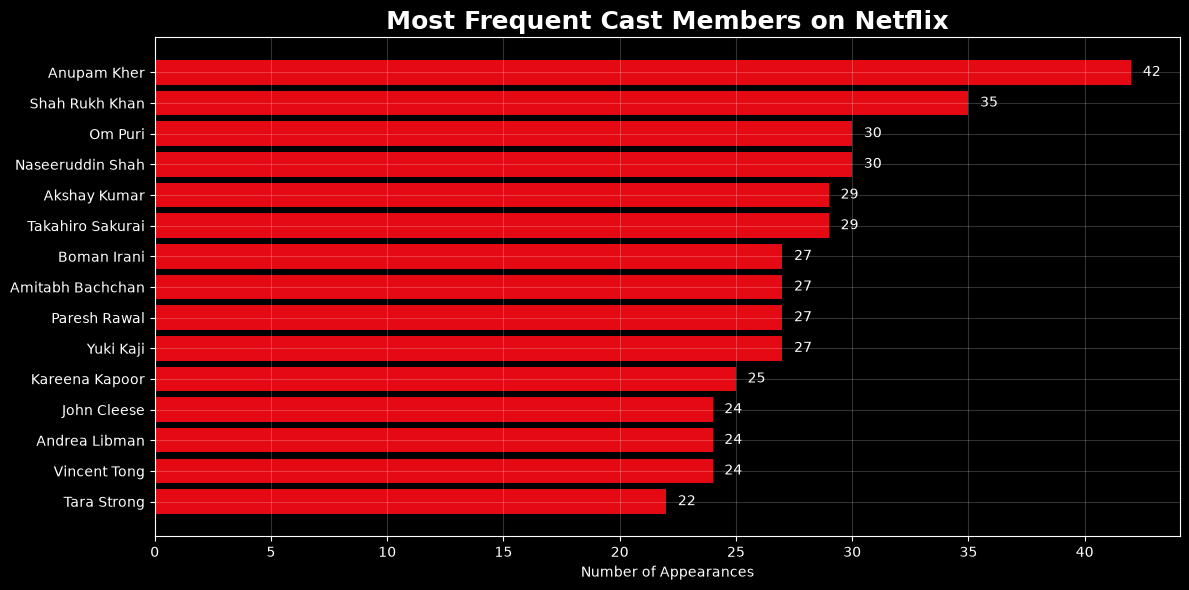

In [122]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    top_cast.index[::-1],
    top_cast.values[::-1],
    color=NETFLIX_RED
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center",
        color="white"
    )

plt.title(
    "Most Frequent Cast Members on Netflix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Appearances")

plt.grid(alpha=0.2)

plt.tight_layout()
save_chart("top_cast_members.png")
plt.show()

## Dashboard Candidate

⚠️ Optional

Reason:

Interesting for content exploration and user engagement, but less important than metrics such as genres, countries, ratings, and content growth.

Include only if sufficient dashboard space is available.

# Key Findings

1. Netflix's catalog expanded rapidly after 2015.

2. Movies dominate the catalog, although TV Shows experienced strong growth after 2015.

3. The United States and India contribute the largest share of content.

4. Netflix relies heavily on international content, with International Movies being the largest genre category.

5. More than 60% of content is targeted toward mature and young-adult audiences (TV-MA and TV-14).

6. Different countries specialize in different content types, with India being movie-focused and countries like Japan contributing relatively more TV content.